##### Imports

In [6]:
# %pip install -r requirements.txt

In [7]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

warnings.filterwarnings('ignore')

# Loading Saved Model

In [8]:
# Read all files in base model path
model_path = Path('saved_models/KAMA_MSR') / 'us_equity' / '20251007'

model_files = list(model_path.glob('*.pkl'))
model_files

# get asset names from model files
ASSET_NAMES = [f.stem.split('_')[0] for f in model_files]
ASSET_NAMES

['SPDR Gold Shares',
 'Consumer Discretionary Select Sector SPDR',
 'Consumer Staples Select Sector SPDR',
 'iShares Micro-Cap ETF',
 'iShares Russell 2000 ETF',
 'Vanguard FTSE Europe ETF',
 'Financial Select Sector SPDR',
 'iShares S&P 500 Value ETF',
 'Invesco DB Agriculture',
 'Health Care Select Sector SPDR',
 'iShares MSCI Japan ETF',
 'iShares U.S. Real Estate ETF',
 'iShares Russell 2000 Value ETF',
 'iShares S&P 500 Growth ETF',
 'Invesco QQQ Trust',
 'United States Natural Gas Fund',
 'SPDR Dow Jones Industrial Average ETF',
 'SPDR S&P 500 ETF',
 'iShares Russell 2000 Growth ETF',
 'iShares Russell Mid-Cap ETF',
 'Technology Select Sector SPDR',
 'United States Oil Fund',
 'Energy Select Sector SPDR',
 'Materials Select Sector SPDR',
 'Utilities Select Sector SPDR',
 'iShares Silver Trust',
 'Vanguard FTSE Emerging Markets ETF',
 'iShares MSCI India ETF',
 'Industrial Select Sector SPDR',
 'iShares China Large-Cap ETF',
 'Vanguard FTSE Developed Markets ETF']

LOADED MODEL INFORMATION

2. KAMA PARAMETERS:
----------------------------------------
KAMA n: 18
KAMA n_fast: 12
    KAMA k_fast: 0.153846
KAMA n_slow: 33
    KAMA k_slow: 0.058824
gamma: 0.65

3. MSR PRIORS:
----------------------------------------
mean_prior_mean: 0.0
mean_prior_var: 0.1
beta_prior_mean: 0.0
beta_prior_var: 1.0
sigma_prior_shape: 2.0
sigma_prior_scale: 0.1
transition_prior_alpha: 8.0

4. MODEL CONFIGURATION:
----------------------------------------
use_three_state_msr: False
Number of combined regimes: 4
MSR n_regimes: 2

5. DATA INFORMATION:
----------------------------------------
Price data length: 7743
Return data length: 7742
Regime labels length: 7724
Regime changes: 118

6. MSR PARAMETERS (Post-Fit):
----------------------------------------
MSR Means (μ):
  Regime 0: 0.000585
  Regime 1: -0.002767

MSR Betas (β):
  Regime 0: -0.0129
  Regime 1: -0.0513

MSR Standard Deviations (σ):
  Regime 0: 0.010674
  Regime 1: 0.035723

MSR Transition Probabilities:
     

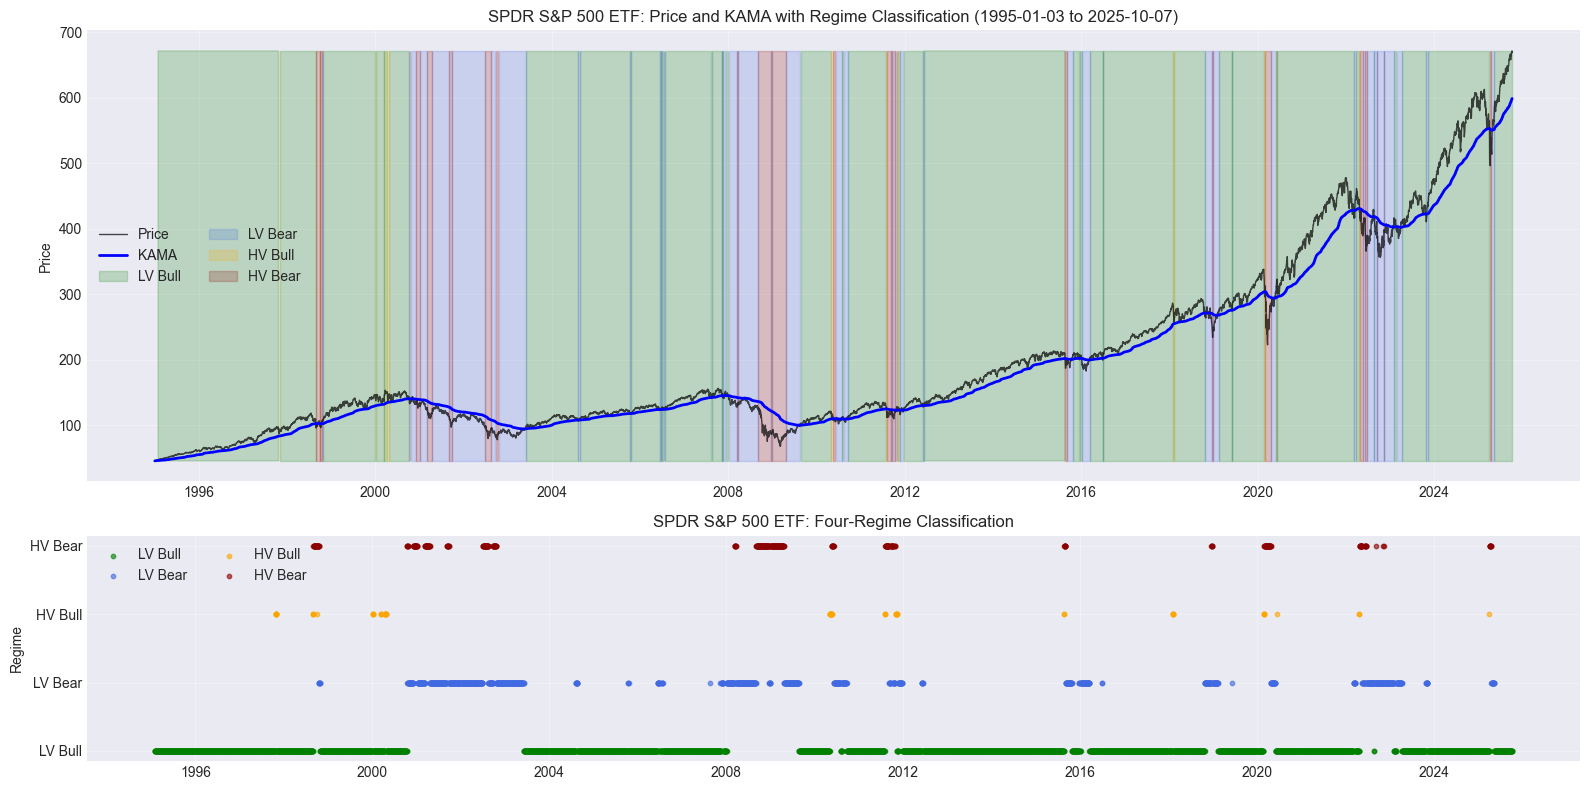

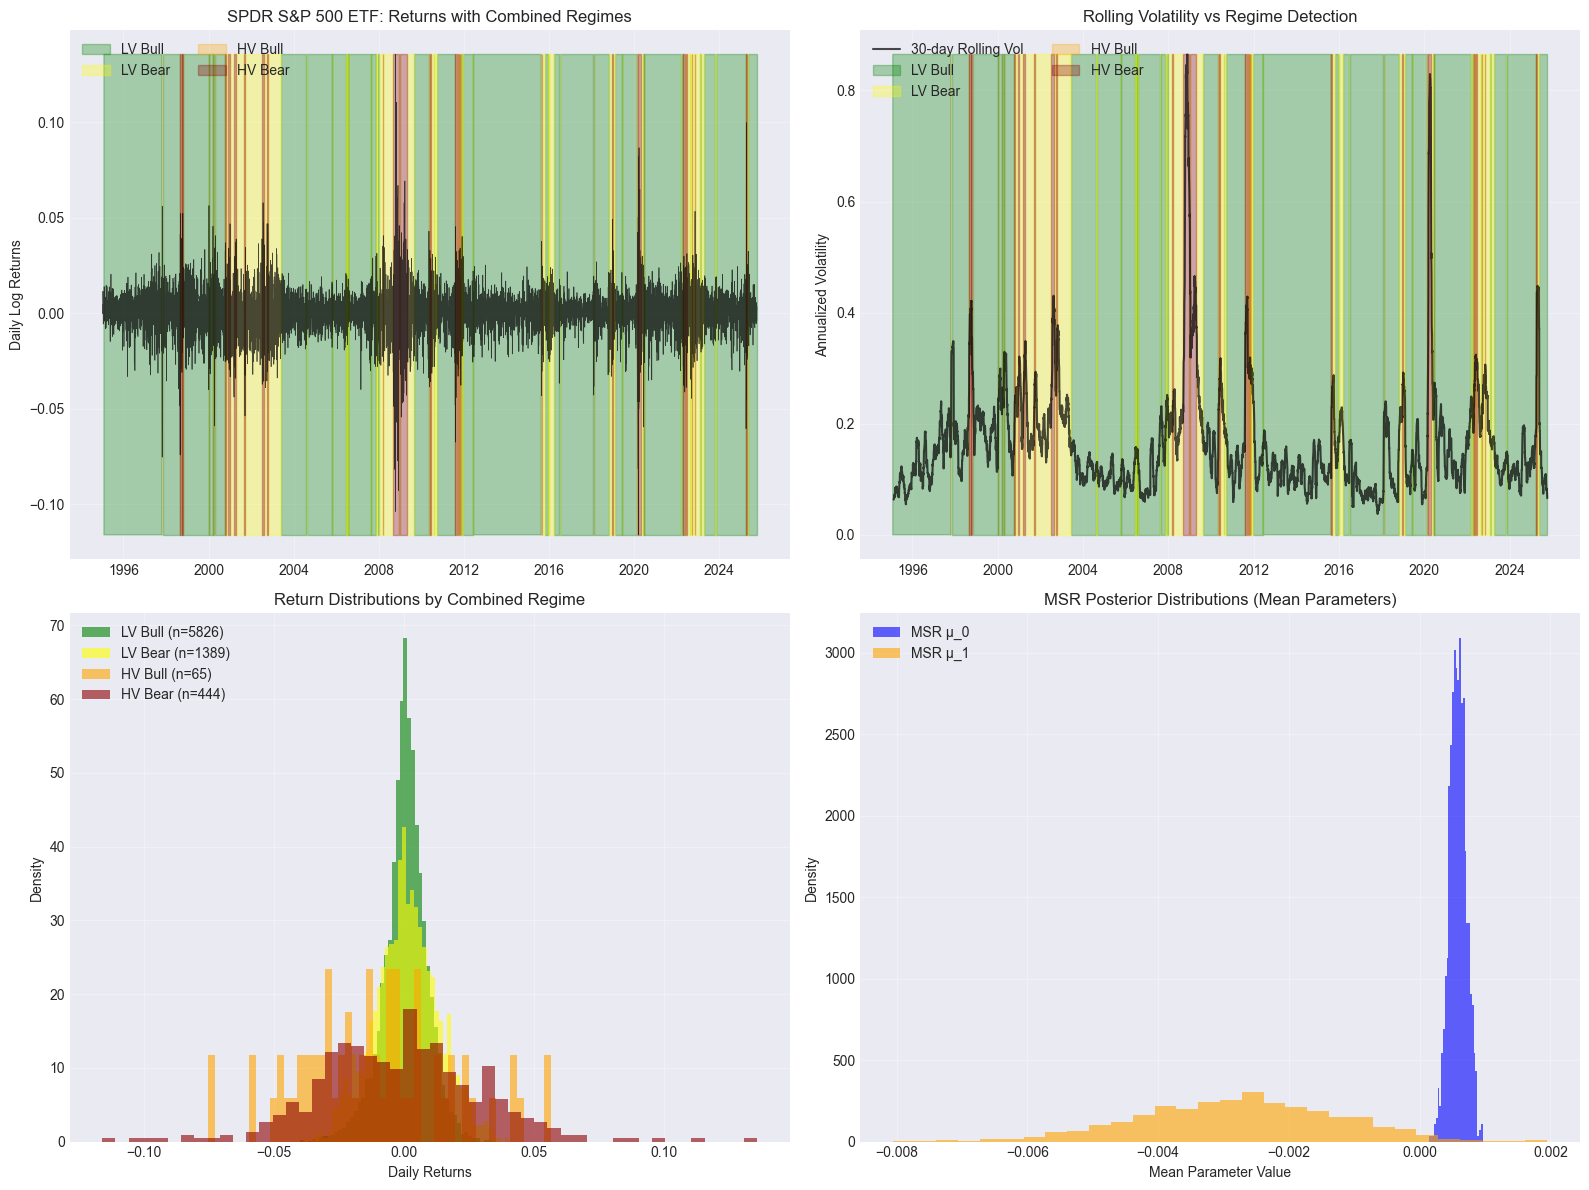


KAMA+MSR MODEL DIAGNOSTICS - SPDR S&P 500 ETF

Combined Model Fit Statistics:
Log-Likelihood: 23822.89
Average Log-Likelihood: 3.08

KAMA Tracking Error (vs returns): 0.011968
KAMA Efficiency Ratio (mean): 0.2447

Regime Stability:
  Total regime changes: 118
  Average regime duration: 65.1 periods
  Change frequency: 1.52%


In [9]:
def load_and_analyze_KAMA_MSR_model(asset_name: str, n_regimes: int, sub_folder: str, edte_sub_folder: str) -> None:
    pkl_file_path = f'saved_models/KAMA_MSR/{sub_folder}/{edte_sub_folder}/{asset_name}_KAMA-MSR_{n_regimes*2}-regimes.pkl'
    with open(pkl_file_path, 'rb') as f:
        loaded_model = pickle.load(f)

    print("="*80)
    print("LOADED MODEL INFORMATION")
    print("="*80)

    # ============================================================================
    # 2. ACCESS KAMA PARAMETERS
    # ============================================================================
    print("\n2. KAMA PARAMETERS:")
    print("-" * 40)
    print(f"KAMA n: {loaded_model.kama.n}")
    print(f"KAMA n_fast: {loaded_model.kama.n_fast}")
    print(f"    KAMA k_fast: {loaded_model.kama.k_fast:.6f}")
    print(f"KAMA n_slow: {loaded_model.kama.n_slow}")
    print(f"    KAMA k_slow: {loaded_model.kama.k_slow:.6f}")
    print(f"gamma: {loaded_model.gamma}")

    # ============================================================================
    # 3. ACCESS PRIORS (AFTER OPTIMIZATION)
    # ============================================================================
    print("\n3. MSR PRIORS:")
    print("-" * 40)

    # The priors used during model initialization
    priors = loaded_model.msr.priors
    for param, value in priors.items():
        print(f"{param}: {value}")

    # ============================================================================
    # 4. ACCESS MODEL CONFIGURATION
    # ============================================================================
    print("\n4. MODEL CONFIGURATION:")
    print("-" * 40)
    print(f"use_three_state_msr: {loaded_model.use_three_state_msr}")
    print(f"Number of combined regimes: {loaded_model.n_combined_regimes}")
    print(f"MSR n_regimes: {loaded_model.msr.n_regimes}")

    # ============================================================================
    # 5. CHECK DATA DIMENSIONS
    # ============================================================================
    print("\n5. DATA INFORMATION:")
    print("-" * 40)
    if loaded_model.prices is not None:
        print(f"Price data length: {len(loaded_model.prices)}")
        print(f"Return data length: {len(loaded_model.returns)}")
        print(f"Regime labels length: {len(loaded_model.regime_labels.dropna())}")
        print(f"Regime changes: {(loaded_model.regime_labels.diff() != 0).sum()}")

    # ============================================================================
    # 6. ACCESS MSR PARAMETERS (AFTER FITTING)
    # ============================================================================
    print("\n6. MSR PARAMETERS (Post-Fit):")
    print("-" * 40)
    print("MSR Means (μ):")
    for i, mean in enumerate(loaded_model.msr.means):
        print(f"  Regime {i}: {mean:.6f}")

    print("\nMSR Betas (β):")
    for i, beta in enumerate(loaded_model.msr.betas):
        print(f"  Regime {i}: {beta:.4f}")

    print("\nMSR Standard Deviations (σ):")
    for i, std in enumerate(loaded_model.msr.stds):
        print(f"  Regime {i}: {std:.6f}")

    print("\nMSR Transition Probabilities:")
    print("          To Regime:")
    print("From      0       1" + ("       2" if loaded_model.msr.n_regimes == 3 else ""))
    print("Regime")
    for i in range(loaded_model.msr.n_regimes):
        row = f"  {i}    "
        for j in range(loaded_model.msr.n_regimes):
            row += f"  {loaded_model.msr.transition_probs[i,j]:.3f}"
        print(row)


    # ============================================================================
    # 7. RUN ANALYSIS ON LOADED MODEL
    # ============================================================================
    print("\n7. RUNNING FULL ANALYSIS ON LOADED MODEL...")
    loaded_model.analyze_results(data_name=asset_name)
    regime_duration_stats = loaded_model.analyze_regime_durations()
    print("\nRegime Duration Statistics:")
    print(regime_duration_stats)
    loaded_model.regime_characteristics(data_name=asset_name)
    transition_results = loaded_model.regime_transition_analysis(in_depth=False)
    loaded_model.plot_regimes(data_name=asset_name)
    # loaded_model.plot_regime_duration_distribution()
    loaded_model.plot_comprehensive_analysis(data_name=asset_name)
    loaded_model.diagnostics(data_name=asset_name, trace_plots=False)
    
    return loaded_model, transition_results

asset_name = 'SPDR S&P 500 ETF'
n_regimes = 2
sub_folder = 'us_equity'
edte_sub_folder = datetime(2025, 10, 7).strftime('%Y%m%d')
loaded_model, transition_results = load_and_analyze_KAMA_MSR_model(asset_name, n_regimes, sub_folder, edte_sub_folder)

In [10]:
loaded_model.regime_labels

date
1995-01-04    <NA>
1995-01-05    <NA>
1995-01-06    <NA>
1995-01-09    <NA>
1995-01-10    <NA>
              ... 
2025-10-01       0
2025-10-02       0
2025-10-03       0
2025-10-06       0
2025-10-07       0
Length: 7742, dtype: Int64

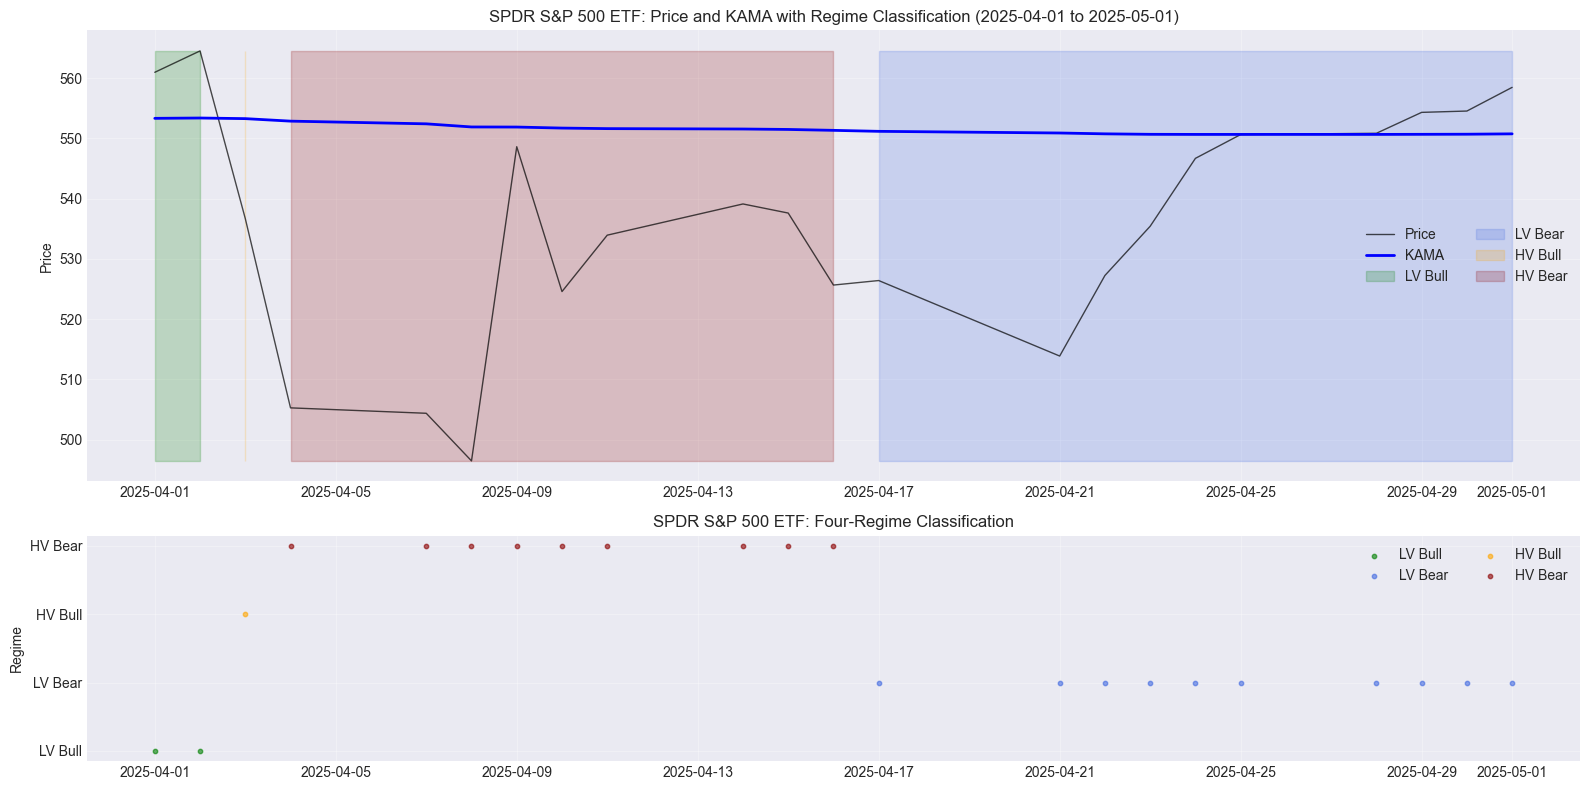

In [11]:
loaded_model.plot_regimes(data_name=asset_name, start_date='2025-04-01', end_date='2025-05-01')

In [12]:
level1_transition_matrix = transition_results[1]['transition_probabilities']\
    .rename(columns={0: 'Low Vol Bull', 1: 'Low Vol Bear', 2: 'High Vol Bull', 3: 'High Vol Bear'},
            index={0: 'Low Vol Bull', 1: 'Low Vol Bear', 2: 'High Vol Bull', 3: 'High Vol Bear'})\
            .rename_axis('From').rename_axis('To', axis=1).round(4) * 100

level1_transition_matrix

To,Low Vol Bull,Low Vol Bear,High Vol Bull,High Vol Bear
From,,,,
Low Vol Bull,99.38,0.39,0.22,0.00
Low Vol Bear,2.09,96.83,0.00,1.08
High Vol Bull,10.77,0.00,76.92,12.31
High Vol Bear,0.00,4.73,0.45,94.82


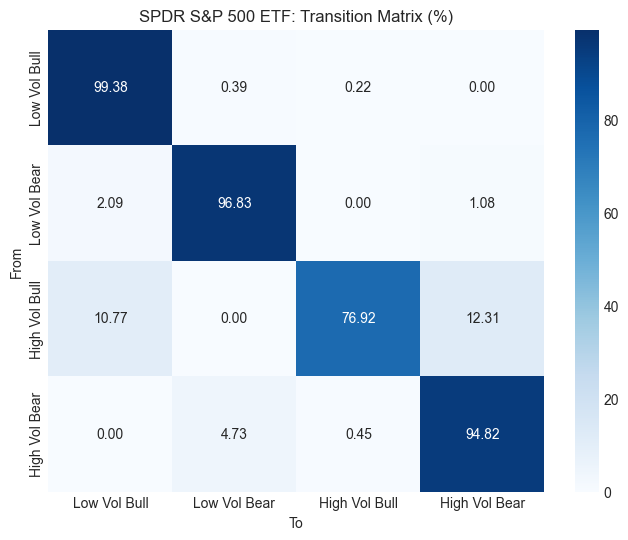

In [13]:
# Heatmap of level 1 transition matrix
plt.figure(figsize=(8, 6))
sns.heatmap(level1_transition_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"{asset_name}: Transition Matrix (%)")
plt.show()

In [14]:
level2_transition_matrix = transition_results[1]['level_two_transition_probabilities']\
    .rename_axis('From').rename_axis('To', axis=1).round(3) * 100

level2_transition_matrix

To,Low Vol Bull,Low Vol Bear,High Vol Bull,High Vol Bear
From,,,,
Low Vol Bull → Low Vol Bear (n=23),82.6,0.0,0.0,17.4
Low Vol Bull → High Vol Bull (n=13),46.2,0.0,0.0,53.8
Low Vol Bear → Low Vol Bull (n=28),0.0,67.9,32.1,0.0
Low Vol Bear → High Vol Bear (n=15),0.0,93.3,6.7,0.0
High Vol Bull → Low Vol Bull (n=7),0.0,57.1,42.9,0.0
High Vol Bull → High Vol Bear (n=8),0.0,87.5,12.5,0.0
High Vol Bear → Low Vol Bear (n=21),47.6,0.0,0.0,52.4
High Vol Bear → High Vol Bull (n=2),50.0,0.0,0.0,50.0


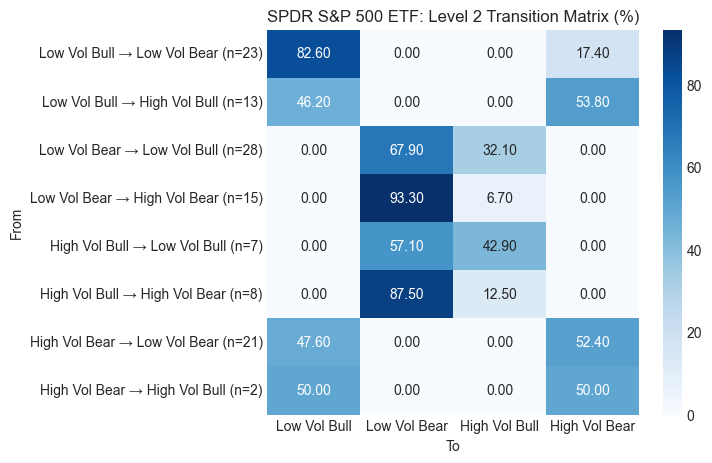

In [15]:
# Heatmap of Level 2 transition matrix
plt.figure(figsize=(6, 5))
sns.heatmap(level2_transition_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"{asset_name}: Level 2 Transition Matrix (%)")
plt.show()